In [1]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
# 2. LOAD DATA

orders = pd.read_csv("orders.csv")
order_products_prior = pd.read_csv("order_products__prior.csv")

In [3]:
# 3. MERGE DATA

data = order_products_prior.merge(
    orders[["order_id", "user_id", "order_number", "order_hour_of_day", "days_since_prior_order"]],
    on="order_id",
    how="left"
)

In [4]:
# 4. FEATURE ENGINEERING

customer_features = orders.groupby("user_id").agg(
    total_orders=("order_number", "max"),
    avg_days_between_orders=("days_since_prior_order", "mean"),
    avg_order_hour=("order_hour_of_day", "mean")
).reset_index()

# Order variability
order_variability = orders.groupby("user_id")["order_number"].var().reset_index()
order_variability.columns = ["user_id", "order_variability"]
customer_features = customer_features.merge(order_variability, on="user_id", how="left")

# Average basket size
basket_size = data.groupby(["user_id", "order_id"]).size().reset_index(name="basket_size")
avg_basket_size = basket_size.groupby("user_id")["basket_size"].mean().reset_index()
avg_basket_size.columns = ["user_id", "avg_basket_size"]
customer_features = customer_features.merge(avg_basket_size, on="user_id", how="left")

# Reorder rate
reorder_rate = data.groupby("user_id")["reordered"].mean().reset_index()
reorder_rate.columns = ["user_id", "reorder_rate"]
customer_features = customer_features.merge(reorder_rate, on="user_id", how="left")

# Fill missing values
customer_features = customer_features.fillna(0)

In [5]:
# 5. LOG TRANSFORM

customer_features["total_orders"] = np.log1p(customer_features["total_orders"])
customer_features["avg_basket_size"] = np.log1p(customer_features["avg_basket_size"])

In [6]:
# 6. TAKE A SUBSET

subset_size = 5000

customer_subset = customer_features.sample(
    n=min(subset_size, len(customer_features)),
    random_state=42
).copy()

print("Subset shape:", customer_subset.shape)

Subset shape: (5000, 7)


In [7]:
# 7. SELECT FEATURES

feature_cols = [
    "total_orders",
    "avg_days_between_orders",
    "avg_order_hour",
    "order_variability",
    "avg_basket_size",
    "reorder_rate"
]

features = customer_subset[feature_cols]

In [8]:
# 8. SCALE FEATURES

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [9]:
# 9. APPLY DBSCAN

# You may tune eps and min_samples
dbscan = DBSCAN(eps=0.8, min_samples=10)

customer_subset["dbscan_cluster"] = dbscan.fit_predict(scaled_features)

print("\nDBSCAN completed.")
print(customer_subset[["user_id", "dbscan_cluster"]].head())


DBSCAN completed.
        user_id  dbscan_cluster
189032   189033               0
113006   113007              -1
40368     40369               0
2152       2153               0
194849   194850               0


In [10]:
# 10. CLUSTER COUNTS

cluster_counts = customer_subset["dbscan_cluster"].value_counts().sort_index()

print("\nCluster Counts:")
print(cluster_counts)


Cluster Counts:
dbscan_cluster
-1     482
 0    4498
 1      20
Name: count, dtype: int64


In [11]:
# 11. NUMBER OF CLUSTERS / NOISE

n_clusters = len(set(customer_subset["dbscan_cluster"])) - (
    1 if -1 in customer_subset["dbscan_cluster"].values else 0
)

n_noise = (customer_subset["dbscan_cluster"] == -1).sum()

print(f"\nEstimated number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")


Estimated number of clusters: 2
Number of noise points: 482


In [12]:
# 12. SILHOUETTE SCORE

# Exclude noise points (-1) before computing silhouette score
clustered_only = customer_subset[customer_subset["dbscan_cluster"] != -1].copy()

if clustered_only["dbscan_cluster"].nunique() > 1:
    clustered_scaled = scaled_features[customer_subset["dbscan_cluster"] != -1]

    score = silhouette_score(
        clustered_scaled,
        clustered_only["dbscan_cluster"]
    )
    print(f"Silhouette Score (excluding noise): {score:.4f}")
else:
    print("Silhouette Score cannot be computed because DBSCAN found fewer than 2 clusters.")


Silhouette Score (excluding noise): 0.6445


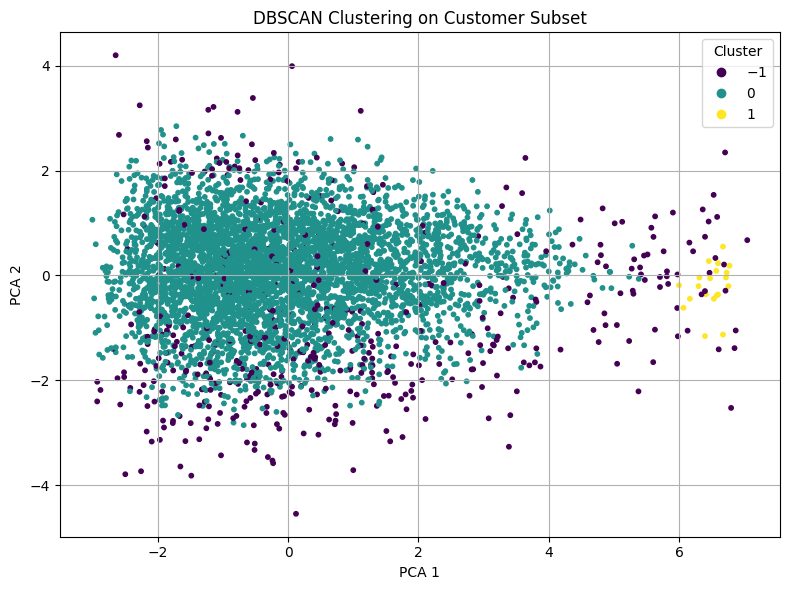

In [13]:
# 13. PCA VISUALIZATION

pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(scaled_features)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_features[:, 0],
    pca_features[:, 1],
    c=customer_subset["dbscan_cluster"],
    s=10
)
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.title("DBSCAN Clustering on Customer Subset")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
# 14. CLUSTER PROFILE

if not clustered_only.empty and clustered_only["dbscan_cluster"].nunique() > 0:
    cluster_profile = clustered_only.groupby("dbscan_cluster")[feature_cols].mean()

    print("\nCluster Profile:")
    print(cluster_profile)
else:
    cluster_profile = pd.DataFrame()
    print("\nNo valid clusters found for profiling.")



Cluster Profile:
                total_orders  avg_days_between_orders  avg_order_hour  \
dbscan_cluster                                                          
0                   2.533060                15.805296       13.666881   
1                   4.603515                 3.235280       13.521957   

                order_variability  avg_basket_size  reorder_rate  
dbscan_cluster                                                    
0                       35.980732         2.285908      0.418159  
1                      822.766667         2.095631      0.769934  


In [15]:
# 15. SAVE RESULTS

customer_subset.to_csv("customer_segmentation_dbscan_results.csv", index=False)

if not cluster_profile.empty:
    cluster_profile.to_csv("customer_segmentation_dbscan_cluster_profile.csv")

print("\nFiles saved:")
print("- customer_segmentation_dbscan_results.csv")
if not cluster_profile.empty:
    print("- customer_segmentation_dbscan_cluster_profile.csv")


Files saved:
- customer_segmentation_dbscan_results.csv
- customer_segmentation_dbscan_cluster_profile.csv
